In [1]:
import pandas as pd
import glob

files = glob.glob('K-*.csv')
print("Files found:", files)

dfs = []
for f in files:
    temp = pd.read_csv(f)
    temp['source_file'] = f
    dfs.append(temp)

df_full = pd.concat(dfs, ignore_index=True)
print("Total rows:", len(df_full))
print("\nRows per kettle:")
print(df_full['Kettle'].value_counts())
print("\nDate range:")
print(df_full['Date'].min(), "to", df_full['Date'].max())

Files found: ['K-12.csv', 'K-13.csv', 'K-15.csv', 'K-16.csv', 'K-9.csv']
Total rows: 645

Rows per kettle:
Kettle
12.0    158
13.0    130
9.0     130
16.0    128
15.0     94
Name: count, dtype: int64

Date range:
01-04-2026 to 31-10-2025


In [2]:
df_full['Date'] = pd.to_datetime(df_full['Date'], dayfirst=True)

print("Date range:")
print(df_full['Date'].min(), "to", df_full['Date'].max())

print("\nRows per month:")
print(df_full['Date'].dt.to_period('M').value_counts().sort_index())

Date range:
2025-05-26 00:00:00 to 2026-06-19 00:00:00

Rows per month:
Date
2025-05    10
2025-06    25
2025-07    50
2025-08    42
2025-09    39
2025-10    60
2025-11    46
2025-12    54
2026-01    52
2026-02    52
2026-03    52
2026-04    54
2026-05    64
2026-06    40
Freq: M, Name: count, dtype: int64


In [3]:
# Anonymize grades
grade_mapping = {grade: f'G{str(i+1).zfill(3)}' for i, grade in enumerate(df_full['Grade'].unique())}
df_full['Grade'] = df_full['Grade'].map(grade_mapping)

# Save mapping privately
import json
with open('grade_mapping_PRIVATE.json', 'w') as f:
    json.dump(grade_mapping, f, indent=2)

# Drop ID column if present
if 'ID' in df_full.columns:
    df_full = df_full.drop(columns=['ID'])

# Save combined anonymized file
df_full.to_csv('upr_batch_data_anonymized.csv', index=False)

print("Done.")
print("Unique grades:", df_full['Grade'].nunique())
print("Shape:", df_full.shape)

Done.
Unique grades: 52
Shape: (645, 136)


In [4]:
# Check what G032 rows look like
print(df_full[df_full['Grade'] == 'G032'][['Date', 'Kettle', 'Grade', 'Planning Batch Size', 'Output']].head(10))

    Date  Kettle Grade  Planning Batch Size       Output
158  NaT     NaN  G032           2258000.00   2331450.68
289  NaT     NaN  G032           3367195.70   3636719.34
384  NaT     NaN  G032           2413000.00   2450739.00
513  NaT     NaN  G032           3530464.90   3585310.00
644  NaT     NaN  G032          32950707.46  33986322.67


In [5]:
# Drop rows where Date is NaT (summary rows)
df_full = df_full[df_full['Date'].notna()].reset_index(drop=True)

# Re-anonymize grades cleanly now that junk rows are gone
grade_mapping = {grade: f'G{str(i+1).zfill(3)}' for i, grade in enumerate(df_full['Grade'].unique())}
df_full['Grade'] = df_full['Grade'].map(grade_mapping)

# Update private mapping file
with open('grade_mapping_PRIVATE.json', 'w') as f:
    json.dump(grade_mapping, f, indent=2)

# Overwrite the anonymized CSV
df_full.to_csv('upr_batch_data_anonymized.csv', index=False)

print("Done.")
print("Total rows:", len(df_full))
print("Unique grades:", df_full['Grade'].nunique())

Done.
Total rows: 640
Unique grades: 51


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Basic yield loss stats
print("=== Yield Loss Stats ===")
print(df_full['ActualYield Loss/(Gain)'].describe())

print("\n=== Batches per Kettle ===")
print(df_full['Kettle'].value_counts().sort_index())

print("\n=== Missing values in step D (downtime) columns ===")
d_cols = [c for c in df_full.columns if c.startswith('D')]
print(df_full[d_cols].isnull().sum())

=== Yield Loss Stats ===
count    640.000000
mean       0.601094
std        1.186999
min       -9.800000
25%        0.100000
50%        0.600000
75%        0.900000
max       14.700000
Name: ActualYield Loss/(Gain), dtype: float64

=== Batches per Kettle ===
Kettle
9.0     130
12.0    158
13.0    130
15.0     94
16.0    128
Name: count, dtype: int64

=== Missing values in step D (downtime) columns ===
Date      0
D         0
D.1       0
D.2       0
D.3       0
D.4       1
D.5      14
D.6      16
D.7      79
D.8     264
D.9     346
D.10    354
D.11    596
D.12    639
D.13    639
D.14    639
D.15    639
D.16    640
dtype: int64


In [7]:
# Get all function columns
func_cols = [c for c in df_full.columns if c.startswith('Function')]

# Collect all unique function names across all step columns
all_functions = pd.Series(dtype=str)
for f in func_cols:
    all_functions = pd.concat([all_functions, df_full[f].dropna()])

print("All unique step functions:")
print(all_functions.value_counts())

All unique step functions:
Cooling Time                      639
Reaction Time                     627
Dropping Time                     623
Reflux Time                       615
Charging Time                     566
Reaction2 Time                    468
Cooling2 Time                     362
Vacuum Time                       355
Charging 1200 Time                314
9200 Addition With Reflux Time    281
Reflux2 Time                      178
Digestion Time                    130
Batch clear time                   98
Washing Time                       24
Charging 270/P & 1200              22
Heating Time                       17
10000 Addition Time                11
Digestion2 time                    11
Charging2 Time                     10
Charge 9001 & Heating               9
Vacuum -2                           6
Cooling & Testing                   3
Packing Time                        3
Styrenation To Dropping Time        1
Cooling3 time                       1
Name: count, dtype: int

In [8]:
# Define core functions to aggregate
core_functions = [
    'Charging Time', 'Reflux Time', 'Reaction Time', 'Reaction2 Time',
    'Cooling Time', 'Cooling2 Time', 'Vacuum Time', 'Dropping Time',
    'Charging 1200 Time', '9200 Addition With Reflux Time'
]

# Get all function and D columns paired together
func_cols = [c for c in df_full.columns if c.startswith('Function')]
d_cols_steps = [c for c in df_full.columns if c.startswith('D.') or c == 'D']

# Make sure they're same length
print("Function cols:", len(func_cols))
print("D cols:", len(d_cols_steps))

Function cols: 16
D cols: 17


In [9]:
# Build function-to-downtime mapping correctly
func_cols = [c for c in df_full.columns if c.startswith('Function')]
d_step_cols = ['D.' + str(i) for i in range(1, 17)]

# Verify pairing
for f, d in zip(func_cols, d_step_cols):
    print(f, "-->", d)

Function --> D.1
Function.1 --> D.2
Function.2 --> D.3
Function.3 --> D.4
Function.4 --> D.5
Function.5 --> D.6
Function.6 --> D.7
Function.7 --> D.8
Function.8 --> D.9
Function.9 --> D.10
Function.10 --> D.11
Function.11 --> D.12
Function.12 --> D.13
Function.13 --> D.14
Function.14 --> D.15
Function.15 --> D.16


In [10]:
# Aggregate downtime by function name for each batch
core_functions = [
    'Charging Time', 'Reflux Time', 'Reaction Time', 'Reaction2 Time',
    'Cooling Time', 'Cooling2 Time', 'Vacuum Time', 'Dropping Time',
    'Charging 1200 Time', '9200 Addition With Reflux Time'
]

func_cols = [c for c in df_full.columns if c.startswith('Function')]
d_step_cols = ['D.' + str(i) for i in range(1, 17)]

# For each batch, sum downtime for each core function
for fn in core_functions:
    col_name = fn.replace(' ', '_').replace('/', '_')
    downtimes = []
    for idx, row in df_full.iterrows():
        total = 0
        for f, d in zip(func_cols, d_step_cols):
            if row[f] == fn and pd.notna(row[d]):
                total += row[d]
        downtimes.append(total)
    df_full[col_name] = downtimes

print("New feature columns added:")
new_cols = [c for c in df_full.columns if any(
    fn.replace(' ', '_').replace('/', '_') in c for fn in core_functions
)]
print(new_cols)
print("\nSample:")
print(df_full[new_cols].head())

C:\Users\rajkh\AppData\Local\Temp\ipykernel_25628\3704246689.py:21: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_full[col_name] = downtimes
C:\Users\rajkh\AppData\Local\Temp\ipykernel_25628\3704246689.py:21: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_full[col_name] = downtimes
C:\Users\rajkh\AppData\Local\Temp\ipykernel_25628\3704246689.py:21: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at

New feature columns added:
['Charging_Time', 'Reflux_Time', 'Reaction_Time', 'Reaction2_Time', 'Cooling_Time', 'Cooling2_Time', 'Vacuum_Time', 'Dropping_Time', 'Charging_1200_Time', '9200_Addition_With_Reflux_Time']

Sample:
   Charging_Time  Reflux_Time  Reaction_Time  Reaction2_Time  Cooling_Time  \
0          -0.42        -0.90          -0.37            1.75          0.40   
1          -0.08        -0.05          -0.23            0.00         -0.15   
2           0.00         3.08           1.17            0.00         -0.35   
3           0.00         0.73           0.73            0.00          0.68   
4           0.00         0.38           1.27           -0.22         -0.02   

   Cooling2_Time  Vacuum_Time  Dropping_Time  Charging_1200_Time  \
0          -0.07         0.98           1.78                1.53   
1          -1.23        -0.20           0.27                0.03   
2           0.00        -0.40          -0.08                0.00   
3           0.00         0.67     

C:\Users\rajkh\AppData\Local\Temp\ipykernel_25628\3704246689.py:21: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_full[col_name] = downtimes
C:\Users\rajkh\AppData\Local\Temp\ipykernel_25628\3704246689.py:21: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_full[col_name] = downtimes
C:\Users\rajkh\AppData\Local\Temp\ipykernel_25628\3704246689.py:21: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at

In [11]:
df_full = df_full.copy()

# Also add total batch downtime and yield loss for reference
print("=== Feature Summary ===")
feature_cols = ['Charging_Time', 'Reflux_Time', 'Reaction_Time', 'Reaction2_Time',
                'Cooling_Time', 'Cooling2_Time', 'Vacuum_Time', 'Dropping_Time',
                'Charging_1200_Time', '9200_Addition_With_Reflux_Time']

print(df_full[feature_cols].describe().round(2))

=== Feature Summary ===
       Charging_Time  Reflux_Time  Reaction_Time  Reaction2_Time  \
count         640.00       640.00         640.00          640.00   
mean            0.78         0.23           0.76            1.25   
std             2.65         1.54           4.37            3.81   
min            -2.58        -2.17         -16.45          -20.07   
25%            -0.14        -0.27          -1.06           -0.16   
50%             0.09         0.00           0.14            0.00   
75%             1.00         0.38           1.27            2.18   
max            32.50        23.52          34.75           26.75   

       Cooling_Time  Cooling2_Time  Vacuum_Time  Dropping_Time  \
count        640.00         640.00       640.00         640.00   
mean           0.04           0.13         0.50           0.43   
std            1.06           0.80         2.40           1.14   
min          -24.17          -1.25       -19.22          -3.50   
25%           -0.17           0.0

In [12]:
# Check missingness in total batch time columns
total_cols = ['A', 'S', 'D', 'I']
print("=== Missing in total batch columns ===")
print(df_full[total_cols].isnull().sum())

# Check missingness in our engineered features
print("\n=== Batches where ALL step features are zero (no step data at all) ===")
all_zero = (df_full[feature_cols] == 0).all(axis=1)
print("Count:", all_zero.sum())

# Check yield loss missingness
print("\n=== Missing yield loss ===")
print(df_full['ActualYield Loss/(Gain)'].isnull().sum())

# Show a sample of problematic rows
print("\n=== Sample rows with missing A or S ===")
print(df_full[df_full['A'].isnull() | df_full['S'].isnull()][
    ['Date', 'Kettle', 'Grade', 'A', 'S', 'D', 'ActualYield Loss/(Gain)']
].head(10))

=== Missing in total batch columns ===
A    0
S    0
D    0
I    0
dtype: int64

=== Batches where ALL step features are zero (no step data at all) ===
Count: 0

=== Missing yield loss ===
0

=== Sample rows with missing A or S ===
Empty DataFrame
Columns: [Date, Kettle, Grade, A, S, D, ActualYield Loss/(Gain)]
Index: []


In [13]:
# Check zeros in total batch actual and standard time
print("=== Zero values in total batch A and S ===")
print("A == 0:", (df_full['A'] == 0).sum())
print("S == 0:", (df_full['S'] == 0).sum())

# Check zeros in engineered step features
# A zero here could mean step doesn't exist for that grade OR data entry issue
print("\n=== Zero counts in step features ===")
for col in feature_cols:
    zeros = (df_full[col] == 0).sum()
    print(f"{col}: {zeros} zeros ({zeros/len(df_full)*100:.1f}%)")

=== Zero values in total batch A and S ===
A == 0: 0
S == 0: 50

=== Zero counts in step features ===
Charging_Time: 98 zeros (15.3%)
Reflux_Time: 53 zeros (8.3%)
Reaction_Time: 17 zeros (2.7%)
Reaction2_Time: 175 zeros (27.3%)
Cooling_Time: 32 zeros (5.0%)
Cooling2_Time: 298 zeros (46.6%)
Vacuum_Time: 292 zeros (45.6%)
Dropping_Time: 42 zeros (6.6%)
Charging_1200_Time: 335 zeros (52.3%)
9200_Addition_With_Reflux_Time: 376 zeros (58.8%)


In [14]:
# Find grades with S == 0 and check if they have other batches with valid S
missing_s = df_full[df_full['S'] == 0]['Grade'].value_counts()
print("=== Grades with missing S and their zero counts ===")
print(missing_s)

print("\n=== Total batches per affected grade ===")
for grade in missing_s.index:
    total = len(df_full[df_full['Grade'] == grade])
    valid = len(df_full[(df_full['Grade'] == grade) & (df_full['S'] != 0)])
    print(f"{grade}: {total} total, {valid} with valid S, {total-valid} missing S")

=== Grades with missing S and their zero counts ===
Grade
G040    8
G025    5
G023    4
G020    3
G031    3
G045    3
G004    3
G015    2
G021    2
G035    2
G036    2
G009    2
G014    1
G019    1
G024    1
G037    1
G038    1
G046    1
G022    1
G050    1
G017    1
G051    1
G027    1
Name: count, dtype: int64

=== Total batches per affected grade ===
G040: 63 total, 55 with valid S, 8 missing S
G025: 5 total, 0 with valid S, 5 missing S
G023: 4 total, 0 with valid S, 4 missing S
G020: 11 total, 8 with valid S, 3 missing S
G031: 3 total, 0 with valid S, 3 missing S
G045: 28 total, 25 with valid S, 3 missing S
G004: 38 total, 35 with valid S, 3 missing S
G015: 2 total, 0 with valid S, 2 missing S
G021: 13 total, 11 with valid S, 2 missing S
G035: 2 total, 0 with valid S, 2 missing S
G036: 2 total, 0 with valid S, 2 missing S
G009: 11 total, 9 with valid S, 2 missing S
G014: 1 total, 0 with valid S, 1 missing S
G019: 1 total, 0 with valid S, 1 missing S
G024: 1 total, 0 with valid S, 1

In [15]:
# Fill S where possible from same grade median
df_full['S'] = df_full['S'].replace(0, pd.NA)

df_full['S'] = df_full.groupby('Grade')['S'].transform(
    lambda x: x.fillna(x.median())
)

# Drop remaining rows where S is still null (grades with no valid S at all)
before = len(df_full)
df_full = df_full[df_full['S'].notna()].reset_index(drop=True)
after = len(df_full)

print(f"Dropped {before - after} batches with no valid standard time")
print(f"Remaining batches: {after}")

# Verify no zeros remain
print(f"S == 0 remaining: {(df_full['S'] == 0).sum()}")
print(f"S is null remaining: {df_full['S'].isnull().sum()}")

Dropped 25 batches with no valid standard time
Remaining batches: 615
S == 0 remaining: 0
S is null remaining: 0


## Step-Yield Loss Correlation Analysis

Pearson correlation between per-step downtime deviation and batch yield loss.
Dropping and Reaction steps show strongest positive correlation — extended time 
in these steps is associated with higher yield loss. Vacuum time deviation is 
third strongest. Reaction2 and Cooling show slight negative correlation, 
suggesting early completion of these steps may also indicate process issues.
Correlations are moderate due to multi-grade dataset (51 grades).

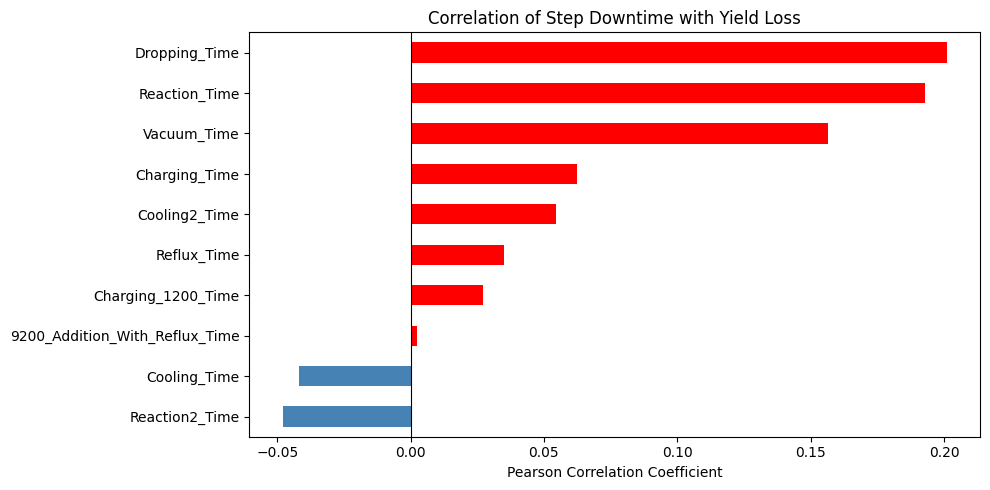


Correlation values:
Reaction2_Time                   -0.048
Cooling_Time                     -0.042
9200_Addition_With_Reflux_Time    0.002
Charging_1200_Time                0.027
Reflux_Time                       0.035
Cooling2_Time                     0.055
Charging_Time                     0.062
Vacuum_Time                       0.156
Reaction_Time                     0.193
Dropping_Time                     0.201
Name: ActualYield Loss/(Gain), dtype: float64


In [16]:
import matplotlib.pyplot as plt

feature_cols = ['Charging_Time', 'Reflux_Time', 'Reaction_Time', 'Reaction2_Time',
                'Cooling_Time', 'Cooling2_Time', 'Vacuum_Time', 'Dropping_Time',
                'Charging_1200_Time', '9200_Addition_With_Reflux_Time']

correlations = df_full[feature_cols + ['ActualYield Loss/(Gain)']].corr()['ActualYield Loss/(Gain)'].drop('ActualYield Loss/(Gain)')

plt.figure(figsize=(10, 5))
colors = ['red' if x > 0 else 'steelblue' for x in correlations.sort_values()]
correlations.sort_values().plot(kind='barh', color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Correlation of Step Downtime with Yield Loss')
plt.xlabel('Pearson Correlation Coefficient')
plt.tight_layout()
plt.savefig('step_yield_correlation.png', dpi=150)
plt.show()

print("\nCorrelation values:")
print(correlations.sort_values().round(3))

<Figure size 800x500 with 0 Axes>

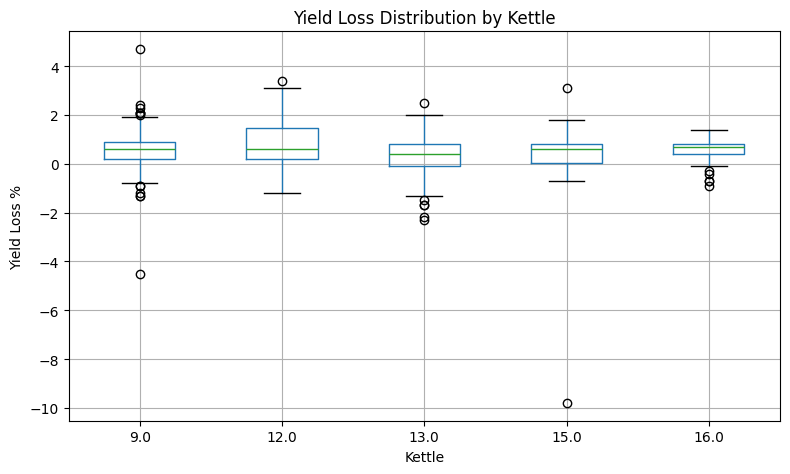

In [17]:
plt.figure(figsize=(8, 5))
df_full.boxplot(column='ActualYield Loss/(Gain)', by='Kettle', figsize=(8,5))
plt.title('Yield Loss Distribution by Kettle')
plt.suptitle('')
plt.xlabel('Kettle')
plt.ylabel('Yield Loss %')
plt.tight_layout()
plt.savefig('kettle_yield_boxplot.png', dpi=150)
plt.show()

## Yield Loss by Kettle

Kettle 12 shows consistently higher yield loss with wider spread.
Kettles 9 and 16 are most consistent performers.
Kettle 15 shows one extreme outlier (-9.8%) likely due to a 
measurement or data entry anomaly — excluded from outlier-sensitive analysis.
All kettles maintain median yield loss within acceptable 0.5–1% range.

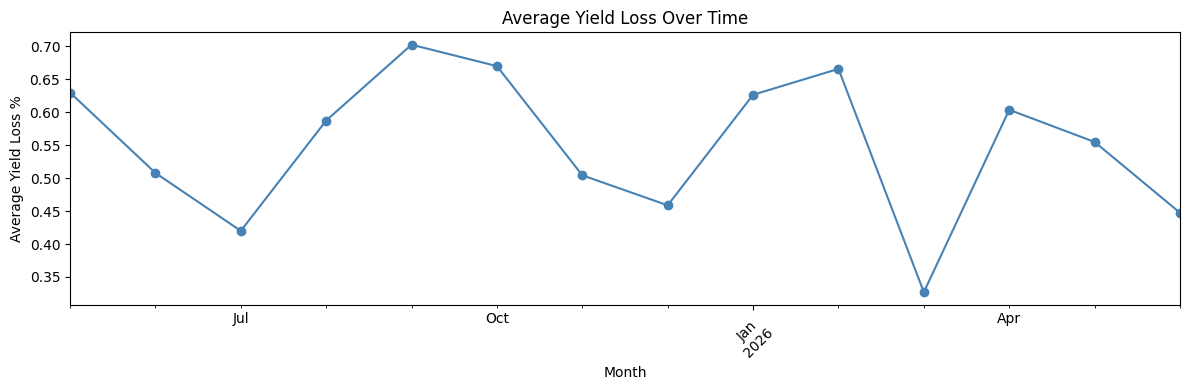

In [18]:
df_full['Month'] = df_full['Date'].dt.to_period('M')
monthly = df_full.groupby('Month')['ActualYield Loss/(Gain)'].mean()

plt.figure(figsize=(12, 4))
monthly.plot(marker='o', color='steelblue')
plt.title('Average Yield Loss Over Time')
plt.xlabel('Month')
plt.ylabel('Average Yield Loss %')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('yield_loss_trend.png', dpi=150)
plt.show()

## Yield Loss Trend Over Time

Average monthly yield loss ranges from 0.33% to 0.70% — indicating a 
stable, well-controlled process with no long-term drift.
Peak yield loss in October 2025 warrants investigation into grade mix 
or operational factors that month. No clear seasonal pattern is apparent, 
suggesting yield loss is driven more by grade-specific and step-level 
factors than by seasonal conditions.

In [19]:
df_model = df_full[df_full['S'] != 0].copy()
df_model.to_csv('upr_model_ready.csv', index=False)
print("Saved. Shape:", df_model.shape)

Saved. Shape: (615, 147)


In [20]:
print("Dataset summary:")
print(f"Total batches: {len(df_model)}")
print(f"Kettles: {sorted(df_model['Kettle'].unique())}")
print(f"Unique grades: {df_model['Grade'].nunique()}")
print(f"Date range: {df_model['Date'].min().date()} to {df_model['Date'].max().date()}")
print(f"Features engineered: {len(feature_cols)}")
print(f"\nKey findings:")
print(f"- Strongest yield loss predictors: Dropping_Time (0.20), Reaction_Time (0.19), Vacuum_Time (0.16)")
print(f"- Kettle 12 shows highest median yield loss")
print(f"- Monthly yield loss stable between 0.33-0.70%")

Dataset summary:
Total batches: 615
Kettles: [np.float64(9.0), np.float64(12.0), np.float64(13.0), np.float64(15.0), np.float64(16.0)]
Unique grades: 38
Date range: 2025-05-26 to 2026-06-19
Features engineered: 10

Key findings:
- Strongest yield loss predictors: Dropping_Time (0.20), Reaction_Time (0.19), Vacuum_Time (0.16)
- Kettle 12 shows highest median yield loss
- Monthly yield loss stable between 0.33-0.70%
